<a href="https://colab.research.google.com/github/Aaditya-Ranjan/CV-Mini-Projects/blob/main/traffic_sign_detection_imp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import os


In [ ]:
data_dir = "/content/traffic sign dataset"
print("Folders inside:", os.listdir(data_dir)[:5])


Folders inside: ['No stopping', '.ipynb_checkpoints', 'No parking.', 'give way', 'NO entry']


In [ ]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_set = datagen.flow_from_directory(
    data_dir,
    target_size=(48, 48),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

valid_set = datagen.flow_from_directory(
    data_dir,
    target_size=(48, 48),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)


Found 345 images belonging to 14 classes.
Found 79 images belonging to 14 classes.


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(train_set.num_classes, activation='softmax')
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,661,646 (6.34 MB)

 Trainable params: 1,661,646 (6.34 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_set,
    validation_data=valid_set,
    epochs=10
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 157ms/step - accuracy: 0.1209 - loss: 2.5893 - val_accuracy: 0.2405 - val_loss: 2.2955
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.2879 - loss: 2.1912 - val_accuracy: 0.4810 - val_loss: 1.9084
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.4957 - loss: 1.7520 - val_accuracy: 0.5949 - val_loss: 1.5520
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.5756 - loss: 1.3859 - val_accuracy: 0.6456 - val_loss: 1.3205
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 125ms/step - accuracy: 0.6200 - loss: 1.2459 - val_accuracy: 0.6582 - val_loss: 1.1577
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.6861 - loss: 1.0283 - val_accuracy: 0.6456 - val_loss: 1.1793
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.6982 - loss: 0.9313 - val_accuracy: 0.6709 - val_loss: 1.1669
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.8215 - loss: 0.7102 - val_accuracy: 0.6709 - val_loss: 1.1383
Epo

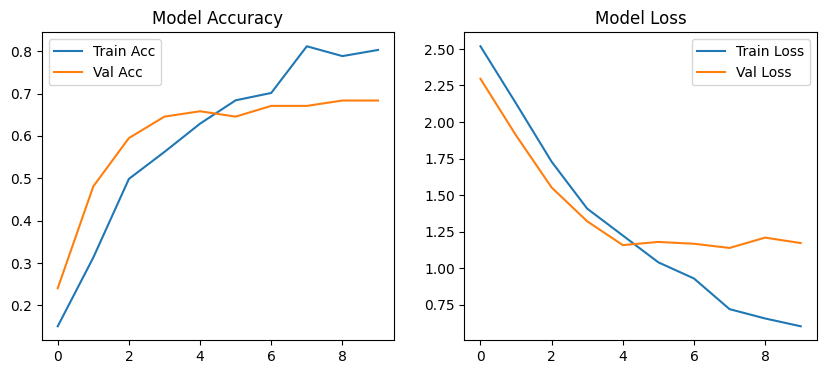

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title("Model Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title("Model Loss")

plt.show()


In [ ]:
model.save("/content/road_sign_cnn_model.h5")
print("✅ Model saved successfully!")


✅ Model saved successfully!


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = "/content/traffic sign dataset/No stopping/22_original_65_original_65.png_09e79b15-6a7a-4a3a-b0ef-8efd6dfaa007.png_837de2e7-59d4-47d7-b9d8-27db93a9c9f4.png"  # sample image
img = image.load_img(img_path, target_size=(48,48))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)/255.0

pred = model.predict(img_array)
predicted_class = list(train_set.class_indices.keys())[np.argmax(pred)]
print("🚦 Predicted Road Sign:", predicted_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
🚦 Predicted Road Sign: No stopping
